In [1]:
import dpluspy
import demes 
import moments
import msprime
import numpy as np

In [9]:
"""
The underlying model `model` has symmetric child deme sizes.
"""

# Define paths to models
model0_file = "notebook_models/graph0.yaml"
params0_file = "notebook_models/params0.yaml"
model1_file = "notebook_models/graph1.yaml"
params1_file = "notebook_models/params1.yaml"

true_model_file = model0_file

# Set up models, parameters and write them to disk.
model0_str = """time_units: generations
demes:
- name: A
  epochs:
  - {end_time: 5000, start_size: 15000}
- name: popX
  ancestors: [A]
  epochs:
  - {end_time: 0, start_size: 20000}
- name: popY
  ancestors: [A]
  epochs:
  - {end_time: 0, start_size: 20000}
"""

params0_str = """parameters: 
- name: N_A
  lower_bound: 10
  upper_bound: 1e5
  values: 
    - demes: 
        A: 
          epochs: 
            0: start_size
- name: T_XY
  lower_bound: 10
  upper_bound: 1e5
  values: 
    - demes: 
        A: 
          epochs: 
            0: end_time
- name: N_X_Y
  lower_bound: 10
  upper_bound: 1e5
  values: 
    - demes: 
        popX: 
          epochs: 
            0: start_size
        popY: 
          epochs: 
            0: start_size
"""

model1_str = model0_str

params1_str = """parameters: 
- name: N_A
  lower_bound: 10
  upper_bound: 1e5
  values: 
    - demes: 
        A: 
          epochs: 
            0: start_size
- name: T_XY
  lower_bound: 10
  upper_bound: 1e5
  values: 
    - demes: 
        A: 
          epochs: 
            0: end_time
- name: N_X
  lower_bound: 10
  upper_bound: 1e5
  values: 
    - demes: 
        popX: 
          epochs: 
            0: start_size
- name: N_Y
  lower_bound: 10
  upper_bound: 1e5
  values: 
    - demes: 
        popY: 
          epochs: 
            0: start_size
"""

with open(model0_file, "w") as fout:
    fout.write(model0_str)
with open(params0_file, "w") as fout:
    fout.write(params0_str)

with open(model1_file, "w") as fout:
    fout.write(model1_str)
with open(params1_file, "w") as fout:
    fout.write(params1_str)

In [10]:
# Parameters
r = 1e-8
u = 1.3e-8
L = int(5e6)
n_reps = 100
pop_ids = ["popX", "popY"]
samples = {pop_id: 1 for pop_id in pop_ids}
bins = np.logspace(-6, -2, 17)

In [11]:
# Define simulation and D+ parsing functions

def simulate():
    graph = demes.load(true_model_file)
    demog = msprime.Demography.from_demes(graph)
    tss = msprime.sim_ancestry(
        demography=demog,
        samples=samples,
        sequence_length=L,
        recombination_rate=r,
        num_replicates=n_reps,
    )
    mtss = [msprime.sim_mutations(ts, u) for ts in tss]
    return mtss


def parse_stats(mtss):
    # Parse statistics from simulation results
    intervals = [[1, L + 1, L + 1]]
    pop_mapping = {x: [x] for x in samples} 
    stats = dict()
    for ii, ts in enumerate(mtss):
        if ii == 0:
            stats_ii = dpluspy.parsing.parse_stats(
                ts, 
                get_denoms=True,
                pop_mapping=pop_mapping, 
                r=r, 
                r_bins=bins, 
                intervals=intervals,
                chrom=ii, 
                ts_sample_ids=pop_ids, 
                overhang=None,
                verbose=False
            )
        else:
            stats_ii = dpluspy.parsing.parse_stats(
                ts, 
                get_denoms=False,
                pop_mapping=pop_mapping, 
                r=r, 
                r_bins=bins, 
                intervals=intervals,
                chrom=ii, 
                ts_sample_ids=pop_ids, 
                overhang=None,
                verbose=False
            )
            for jj in range(len(intervals)):
                stats_ii[(ii, jj)]["denoms"] = stats[(0, jj)]["denoms"]
        stats.update(stats_ii)
    return stats

In [12]:
# Run simulations
mtss = simulate()

In [13]:
# Parse statistics and do the bootstrap
stats = parse_stats(mtss)
bootreps = dpluspy.bootstrapping.get_bootstrap_reps(
    stats, num_reps=100, weighted=False)
varcovs = dpluspy.bootstrapping.compute_varcovs(bootreps)
means = dpluspy.bootstrapping.means_across_regions(stats)

In [14]:
def fit_model(graph_file, param_file, output):
    """
    Fit a model, forcing convergence to within 0.1% LL.
    """
    ll_log = []
    thresh = 0.001
    counter = 0
    max_tries = 10
    converged = False
    while not converged:
        ret = dpluspy.inference.optimize(
            graph_file,
            param_file,
            means,
            varcovs,
            pop_ids=pop_ids,
            bins=bins,
            u=u,
            perturb=0.2,
            method="powell",
            log=True,
            max_iter=100,
            verbose=False,
            output=output,
            overwrite=True
        )
        ll = ret[-1]
        print(ll)
        if counter > 0:
            diffs = np.abs((np.array(ll_log) - ll) / ll)
            if np.any(diffs < thresh):
                converged = True
            if counter > max_tries:
                raise ValueError("Failed to obtain convergence")
        ll_log.append(ll)
        counter += 1
    return ret

In [15]:
# Fit the null and underlying (complex) models; force ll1 > ll0
out0 = "notebook_models/fit0.yaml"
out1 = "notebook_models/fit1.yaml"
pnames0, params0, ll0 = fit_model(model0_file, params0_file, out0)
ll1 = -1e10
max_tries = 10
tries = 0
while ll1 <= ll0:
    pnames1, params1, ll1 = fit_model(model1_file, params1_file, out1)
    tries += 1
    if tries > max_tries:
        raise ValueError("Cannot achieve ll1 > ll0")

-15.470773366620957
-15.470771983005474
-1.4562376587102257
-1.4562374276183847


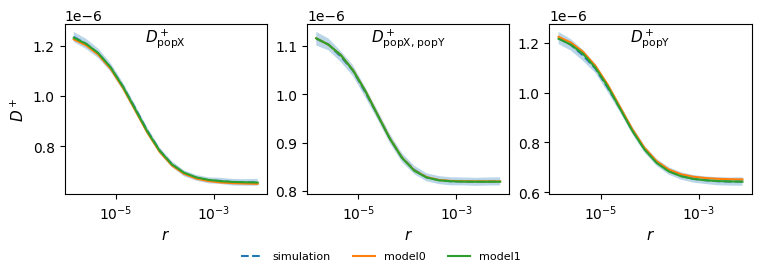

In [17]:
# Plot model fits
model0 = dpluspy.inference.compute_bin_stats(out0, bins=bins, u=u, 
    sampled_demes=pop_ids)
model1 = dpluspy.inference.compute_bin_stats(out1, bins=bins, u=u, 
    sampled_demes=pop_ids)
dpluspy.plotting.plot_D_plus_curves(models=[model0, model1], bins=bins, 
    pop_ids=pop_ids, means=means, varcovs=varcovs, ax_size=2.5,
    labels=["simulation", "model0", "model1"])

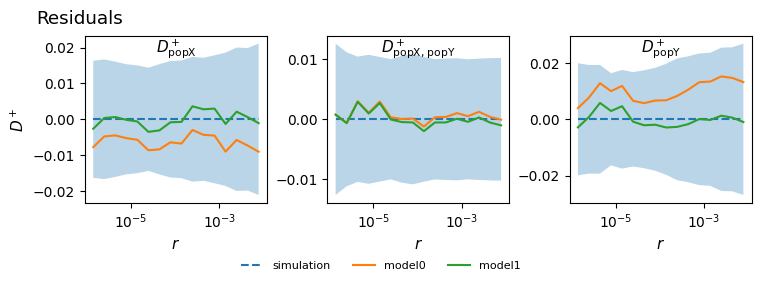

In [18]:
# Plot errors against simulated data
res0 = [(m - s) / s for m, s in zip(model0, means)]
res1 = [(m - s) / s for m, s in zip(model1, means)]
zeros = [np.array([0, 0, 0])] * len(means)
vs = [v / s ** 2 for v, s in zip(varcovs, means)]
dpluspy.plotting.plot_D_plus_curves(models=[res0, res1], bins=bins, 
    varcovs=vs, means=zeros, pop_ids=pop_ids, ax_size=2.5,
    labels=["simulation", "model0", "model1"],
    title="Residuals")

In [20]:
# Summarize fitted parameters
print(f"Model 0 (null) ll = {ll0:.3}")
print("Param\tvalue")
for name, val in zip(pnames0, params0):
    print(f"{name}\t{val:.3}")

print(f"\nModel 1 (full, underlying) ll = {ll1:.3}")
print("Param\tvalue")
for name, val in zip(pnames1, params1):
    print(f"{name}\t{val:.3}")

# We have a single nested parameter which is not at a boundary (m_XY)
weights = (0, 1)
D_naive = 2 * (ll1 - ll0)
p_naive = moments.Godambe.sum_chi2_ppf(D_naive, weights=weights)

print("\nNaive (unadjusted) LR statistic:")
print(f"D =\t{D_naive:.3}")
print(f"p =\t{p_naive:.3}")

Model 0 (null) ll = -15.5
Param	value
N_A	1.5e+04
T_XY	4.9e+03
N_X_Y	1.95e+04

Model 1 (full, underlying) ll = -1.46
Param	value
N_A	1.5e+04
T_XY	4.85e+03
N_X	2.01e+04
N_Y	1.83e+04

Naive (unadjusted) LR statistic:
D =	28.0
p =	1.2e-07


In [22]:
# Compute model uncertainties
def get_uncerts(graph_file, param_file):
    ret = dpluspy.uncerts.GIM_uncerts(
        graph_file, 
        param_file,
        means,
        varcovs,
        pop_ids=pop_ids,
        bins=bins,
        u=u,
        bootreps=bootreps,
        delta=0.01,
        verbose=False
    )
    return ret

_, __, uncerts0 = get_uncerts(out0, params0_file)
_, __, uncerts1 = get_uncerts(out1, params1_file)

print(f"Model 0")
print("Param\t2.5% CI\t97.5% CI")
for name, val, std in zip(pnames0, params0, uncerts0):
    print(f"{name}\t{val - 1.96 * std:.3}\t{val + 1.96 * std:.3}")

print(f"\nModel 1")
print("Param\t2.5% CI\t97.5% CI")
for name, val, std in zip(pnames1, params1, uncerts1):
    print(f"{name}\t{val - 1.96 * std:.3}\t{val + 1.96 * std:.3}")

Model 0
Param	2.5% CI	97.5% CI
N_A	1.49e+04	1.51e+04
T_XY	4.7e+03	5.1e+03
N_X_Y	1.82e+04	2.09e+04

Model 1
Param	2.5% CI	97.5% CI
N_A	1.49e+04	1.51e+04
T_XY	4.65e+03	5.05e+03
N_X	1.84e+04	2.19e+04
N_Y	1.63e+04	2.03e+04


In [ ]:
# Compute the LRT adjustment at model 1 MLE parameters

# Set up complex model arguments
_, __, model_args = dpluspy.uncerts.set_up_model_args(
    model1_file, params1_file, bins=bins, pop_ids=pop_ids, u=u)

p_lrt = params1
steps = np.array([params1[-1] * 0.01])
nested_idx = np.array([3])

# Print a summary of the parameter setup
print("Param\tvalue\tnested?\tstep")
nest_idx = 0
for ii, (name, val) in enumerate(zip(pnames1, p_lrt)):
    nested = True if ii in nested_idx else False
    if nested:
        step = f"{steps[nest_idx]:.3}"
        nest_idx += 1
    else:
        step = "---"
    print(f"{name}\t{val:.3}\t{nested}\t{step}")

adj = dpluspy.uncerts.LRT_adjust(
    p_lrt, 
    model_args, 
    means, 
    varcovs, 
    bootreps, 
    nested_idx, 
    steps=steps,
    verbose=0
)

# Compute the adjusted LR test statistic
D_adj = adj * D_naive
p_adj = moments.Godambe.sum_chi2_ppf(D_adj, weights=weights)

print(f"\nadj =\t{adj:.3}")
print(f"D_adj =\t{D_adj:.3}")
print(f"p =\t{p_adj:.3}")

Param	value	nested?	step
N_A	1.5e+04	False	---
T_XY	4.85e+03	False	---
N_X	2.01e+04	False	---
N_Y	1.83e+04	True	1.83e+02

adj =	0.0705
D_adj =	1.97
p =	0.16


In [25]:
# Compute the LRT adjustment at model 0 MLE parameters

# Set up complex model arguments
_, __, model_args = dpluspy.uncerts.set_up_model_args(
    model1_file, params1_file, bins=bins, pop_ids=pop_ids, u=u)

p_lrt = np.concatenate([params0, [params0[-1]]])
steps = np.array([p_lrt[-1] * 0.01])
nested_idx = np.array([3])

# Print a summary of the parameter setup
print("Param\tvalue\tnested?\tstep")
nest_idx = 0
for ii, (name, val) in enumerate(zip(pnames1, p_lrt)):
    nested = True if ii in nested_idx else False
    if nested:
        step = f"{steps[nest_idx]:.3}"
        nest_idx += 1
    else:
        step = "---"
    print(f"{name}\t{val:.3}\t{nested}\t{step}")

adj = dpluspy.uncerts.LRT_adjust(
    p_lrt, 
    model_args, 
    means, 
    varcovs, 
    bootreps, 
    nested_idx, 
    steps=steps,
    verbose=0
)

# Compute the adjusted LR test statistic
D_adj = adj * D_naive
p_adj = moments.Godambe.sum_chi2_ppf(D_adj, weights=weights)

print(f"\nadj =\t{adj:.3}")
print(f"D_adj =\t{D_adj:.3}")
print(f"p =\t{p_adj:.3}")

Param	value	nested?	step
N_A	1.5e+04	False	---
T_XY	4.9e+03	False	---
N_X	1.95e+04	False	---
N_Y	1.95e+04	True	1.95e+02

adj =	0.0284
D_adj =	0.797
p =	0.372
